# 两台 LACT：从热光光子到两路真实波形和 HBT 互相关

## 结论先行

本 notebook 不把相关性人为放大。它生成恒星、NSB 和稀疏 HBT 相关光子对，
再依次通过 LACT 光线追迹得到的时间核、S17351 微单元恢复、实测单 p.e. 电荷、
SPE 波形、加性噪声与 ADC。最后只用两路波形计算互相关。

执行结果：mAB=2、$|V|^2=0.5$ 的 200 µs 记录只预期0.512个相关对，本次抽到1个；
理论单基线 SNR 仅0.00252，因此原始互相关峰不在已知6 ns时延。DC使两镜相关对的
相对时间 RMS 达0.852 ns，并使所用快速SPE的峰高保留约58.2%。零滞后相关的带宽
最优值约243 MHz；4 ns采样相对该最优值保留约86.8% SNR。

## 1. 设置和 main 参数

In [1]:
from dataclasses import replace
from pathlib import Path
import json, shutil, subprocess, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.signal import correlate

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "python" / "sii_unified.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "python"))
from sii_unified import (
    Instrument, detected_star_rate_hz, hbt_correlated_pair_rate_hz,
    load_measured_spe_template, load_optical_timing_mixture,
    make_fast_spe_template, optical_timing_transfer_efficiency,
    render_pe_waveform, sample_optical_delays_ns,
    simulate_hbt_primary_pe, unit_visibility_snr,
    waveform_cross_correlation, write_main_primary_pe_csv,
)

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'Noto Sans SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
OUTPUT_DIR = REPO_ROOT / "run_logs" / "sii_pair_waveform"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
instrument = Instrument.from_repository(REPO_ROOT)
timing = load_optical_timing_mixture(instrument.optical_timing_kernel_path)
measured_template = load_measured_spe_template(instrument.spe_template_path)

## 2. 正确的相关光子流

当光学相干时间远小于电子学分辨率时，热光的二阶超额相关可以等价写成稀疏相关
光子对：

$$R_{\rm pair}=R_{\star,1}R_{\star,2}\tau_c|V|^2.$$

其余恒星光子和 NSB 都是两镜独立 Poisson 流。相关光子不是“复制全部波形”，
而只是总光子流里极少的一部分。每个光子随后独立抽取各自望远镜的光程延迟。

In [2]:
magnitude = 2.0
visibility2 = 0.50
geometric_delay_ns = 6.0
duration_ns = 200_000.0       # 200 us：完整保存但仍远短于天文积分时间
fast_sample_ns = 0.25         # 4 GS/s 快速读出
star_rate_hz = detected_star_rate_hz(magnitude, instrument)
nsb_rate_hz = instrument.detected_nsb_rate_hz
pair_rate_hz = hbt_correlated_pair_rate_hz(
    star_rate_hz, star_rate_hz, instrument.coherence_area_s, visibility2)

hits, stream_info = simulate_hbt_primary_pe(
    np.random.default_rng(20260825), duration_ns,
    star_rate_hz, nsb_rate_hz, visibility2, instrument,
    optical_timing_mixture=timing,
    geometric_delay_ns=geometric_delay_ns, padding_ns=220.0)
primary_csv = write_main_primary_pe_csv(
    hits, OUTPUT_DIR / "two_telescope_primary_pe.csv")
display(pd.Series(stream_info, name="value").to_frame())
print(f"两镜逐 p.e. 行数：{len(hits):,}")
print(f"main 原生输入：{primary_csv}")

,value
duration_ns,2.000000e+05
padding_ns,2.200000e+02
star_rate_a_hz,2.134503e+08
star_rate_b_hz,2.134503e+08
nsb_rate_a_hz,7.052746e+07
nsb_rate_b_hz,7.052746e+07
visibility2,5.000000e-01
coherence_area_ps,1.123444e-01
hbt_pair_rate_hz,2.559263e+03
expected_hbt_pairs_in_analysis_window,5.118527e-01


两镜逐 p.e. 行数：113,552
main 原生输入：E:\LACT_pylast2\lact_sii_unified\run_logs\sii_pair_waveform\two_telescope_primary_pe.csv


对当前 $m_{AB}=2$、$|V|^2=0.5$，200 µs 中预期的 HBT 对仍远少于随机恒星和
NSB 光子。因此下面两条完整波形看起来几乎独立，这是天文强度干涉的正常尺度。

## 3. 两台望远镜的完整快速电子学波形

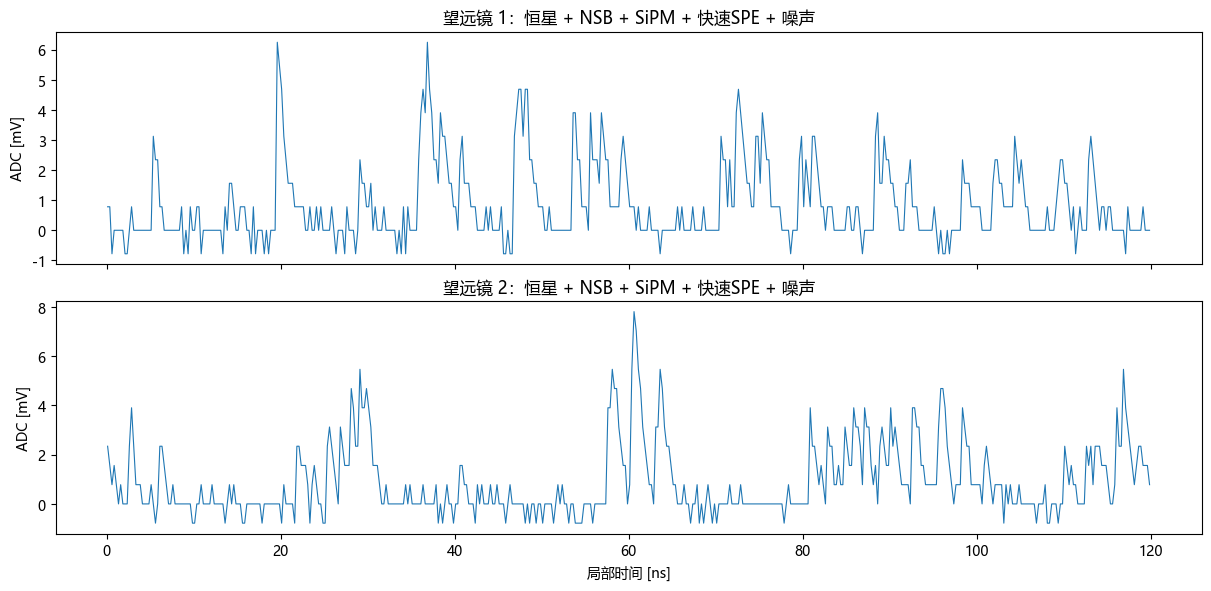

In [3]:
fast_t, fast_v = make_fast_spe_template(rise_ns=0.15, fall_ns=0.80)
fast_v *= measured_template[1].max()  # 只固定峰值增益；真实前端可替换此模板
fast_instrument = replace(instrument, adc_sample_rate_hz=1e9/fast_sample_ns)
waveforms_fast = []
for telescope_id in (0, 1):
    times = hits.loc[hits.telescope_id == telescope_id, "time_ns"].to_numpy()
    waveforms_fast.append(render_pe_waveform(
        np.random.default_rng(3100+telescope_id), times, duration_ns,
        fast_instrument, sample_width_ns=fast_sample_ns,
        template=(fast_t, fast_v)))

view_start, view_end = 20_000.0, 20_120.0
fig, axes = plt.subplots(2, 1, figsize=(12, 5.8), sharex=True, constrained_layout=True)
for telescope_id, (axis, waveform) in enumerate(zip(axes, waveforms_fast)):
    keep = ((waveform["sample_time_ns"] >= view_start) &
            (waveform["sample_time_ns"] <= view_end))
    axis.plot(waveform["sample_time_ns"][keep]-view_start,
              waveform["adc_mv"][keep], lw=.8)
    axis.set(ylabel="ADC [mV]", title=f"望远镜 {telescope_id+1}：恒星 + NSB + SiPM + 快速SPE + 噪声")
axes[-1].set(xlabel="局部时间 [ns]")
fig.savefig(OUTPUT_DIR/"two_fast_waveforms.png", dpi=160)
plt.show()

## 4. 只从两路波形计算互相关

下面没有读取 `hbt_pair_id`，只对两条 ADC 波形去均值后做 FFT 互相关。
由于第二路晚到 6 ns，按这里的顺序峰应位于 $+6$ ns；但单个 200 µs 记录的
统计噪声远大于 HBT 超额相关，所以不能把最高的随机尖峰误认成天文信号。

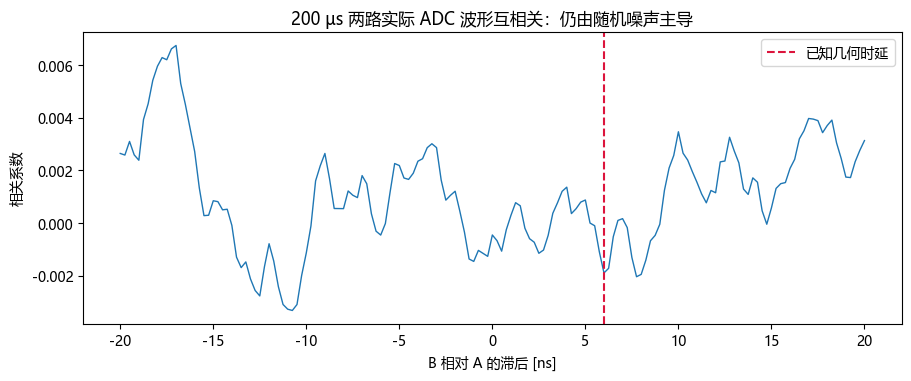

{'raw_max_lag_ns': np.float64(-17.0), 'raw_max_correlation': np.float64(0.006737091415948273), 'off_peak_rms': np.float64(0.002090389460950263)}


In [4]:
lag_fast, corr_fast = waveform_cross_correlation(
    waveforms_fast[1]["adc_mv"], waveforms_fast[0]["adc_mv"],
    fast_sample_ns, 20.0)
raw_peak_lag = lag_fast[np.argmax(corr_fast)]
raw_peak_value = corr_fast.max()
raw_rms = np.std(corr_fast[np.abs(lag_fast-geometric_delay_ns) > 3.0])
fig, ax = plt.subplots(figsize=(9, 3.7), constrained_layout=True)
ax.plot(lag_fast, corr_fast, lw=1)
ax.axvline(geometric_delay_ns, color="crimson", ls="--", label="已知几何时延")
ax.set(title="200 µs 两路实际 ADC 波形互相关：仍由随机噪声主导",
       xlabel="B 相对 A 的滞后 [ns]", ylabel="相关系数")
ax.legend()
fig.savefig(OUTPUT_DIR/"raw_waveform_cross_correlation.png", dpi=160)
plt.show()
print({"raw_max_lag_ns": raw_peak_lag,
       "raw_max_correlation": raw_peak_value,
       "off_peak_rms": raw_rms})

## 5. HBT 波形相关的期望形状：DC 前后

为了看清被随机背景淹没的期望值，这里只计算“一个相关光子对经过两路完整脉冲
响应后的平均互相关”，然后乘以实际的 $R_{\rm pair}$ 即得到物理协方差。
这不是放大后的假观测，而是对微弱信号项做重要抽样。

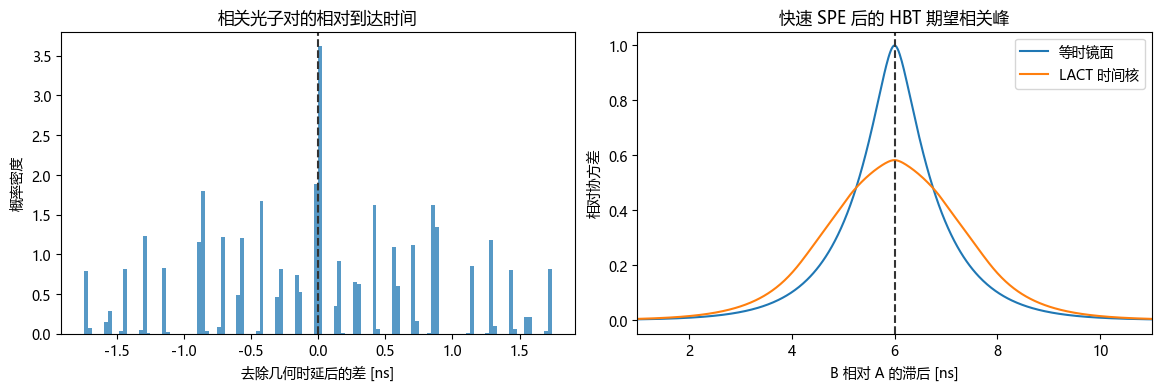

{'single_telescope_timing_rms_ns': 0.6019270827875808, 'pair_delay_rms_ns': np.float64(0.8517382998614969), 'fast_waveform_peak_retention': np.float64(0.5822878178498925)}


In [5]:
response_dt_ns = 0.02
response_lags = np.arange(-15.0, 15.0+response_dt_ns/2, response_dt_ns)
rng_response = np.random.default_rng(52)
response_pairs = 300_000
relative_delay_dc = (geometric_delay_ns
    + sample_optical_delays_ns(rng_response, response_pairs, timing)
    - sample_optical_delays_ns(rng_response, response_pairs, timing))
relative_delay_iso = np.full(response_pairs, geometric_delay_ns)

def expected_pair_waveform_correlation(relative_delays):
    edges = np.r_[response_lags-response_dt_ns/2,
                  response_lags[-1]+response_dt_ns/2]
    delay_hist = np.histogram(relative_delays, bins=edges)[0].astype(float)
    delay_hist /= delay_hist.sum()
    pulse = np.interp(response_lags, fast_t, fast_v, left=0.0, right=0.0)
    pulse_ac = correlate(pulse, pulse, mode="same", method="fft")
    # 以零滞后为中心的循环卷积；范围远大于脉冲和时间核支撑。
    return np.fft.fftshift(np.fft.ifft(
        np.fft.fft(np.fft.ifftshift(delay_hist))
        * np.fft.fft(np.fft.ifftshift(pulse_ac))).real)

expected_iso = expected_pair_waveform_correlation(relative_delay_iso)
expected_dc = expected_pair_waveform_correlation(relative_delay_dc)
normalization = expected_iso.max()
expected_iso /= normalization
expected_dc /= normalization
dc_waveform_peak_retention = expected_dc.max()
pair_delay_rms_ns = np.std(relative_delay_dc-geometric_delay_ns)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8), constrained_layout=True)
axes[0].hist(relative_delay_dc-geometric_delay_ns, bins=120, density=True,
             alpha=.75, label="两镜独立 DC 时间核之差")
axes[0].axvline(0, color='.2', ls='--')
axes[0].set(title="相关光子对的相对到达时间", xlabel="去除几何时延后的差 [ns]",
            ylabel="概率密度")
axes[1].plot(response_lags, expected_iso, label="等时镜面")
axes[1].plot(response_lags, expected_dc, label="LACT 时间核")
axes[1].axvline(geometric_delay_ns, color='.2', ls='--')
axes[1].set(xlim=(1,11), title="快速 SPE 后的 HBT 期望相关峰",
            xlabel="B 相对 A 的滞后 [ns]", ylabel="相对协方差")
axes[1].legend()
fig.savefig(OUTPUT_DIR/"expected_hbt_peak_dc_comparison.png", dpi=160)
plt.show()
print({"single_telescope_timing_rms_ns": timing["rms_spread_ns"],
       "pair_delay_rms_ns": pair_delay_rms_ns,
       "fast_waveform_peak_retention": dc_waveform_peak_retention})

相关峰被展开后，若积分整个峰面积并正确标定，$|V|^2$ 仍然无偏；若只取零延迟
单个采样点，峰高会损失。校准可以恢复平均值，但不能恢复已经损失的信噪比。

## 6. 快速电子学与 4 ns：哪个更合理？

,case,bandwidth_MHz,DC_efficiency,relative_zero_lag_SNR
0,main 4 ns,125.000000,0.929252,0.868284
1,当前长曝光假设,200.000000,0.832691,0.984175
2,时间核下的零滞后最优,242.565415,0.768267,1.000000
3,0.25 ns Nyquist,2000.000000,0.172174,0.643511


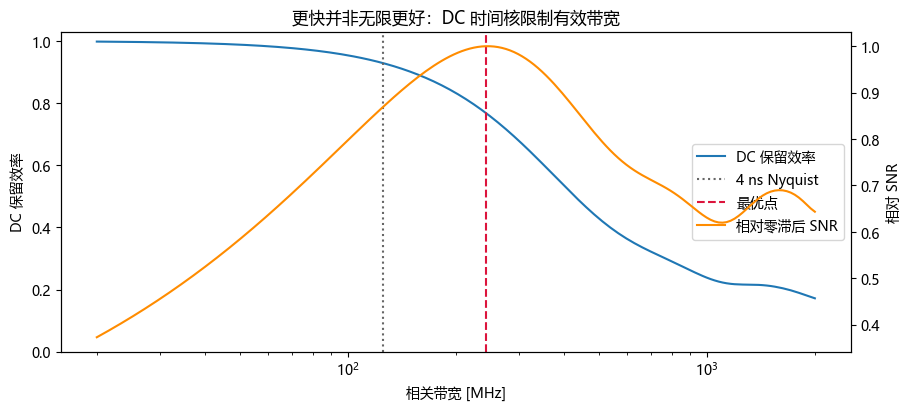

In [6]:
bandwidths_hz = np.geomspace(20e6, 2e9, 180)
timing_efficiency = np.array([
    optical_timing_transfer_efficiency(timing, bandwidth)
    for bandwidth in bandwidths_hz])
zero_lag_snr_metric = timing_efficiency*np.sqrt(bandwidths_hz)
best_index = np.argmax(zero_lag_snr_metric)
best_bandwidth_hz = bandwidths_hz[best_index]
cases = pd.DataFrame([
    {"case":"main 4 ns", "bandwidth_MHz":125.0},
    {"case":"当前长曝光假设", "bandwidth_MHz":200.0},
    {"case":"时间核下的零滞后最优", "bandwidth_MHz":best_bandwidth_hz/1e6},
    {"case":"0.25 ns Nyquist", "bandwidth_MHz":2000.0},
])
cases["DC_efficiency"] = [optical_timing_transfer_efficiency(
    timing, value*1e6) for value in cases.bandwidth_MHz]
cases["relative_zero_lag_SNR"] = (
    cases.DC_efficiency*np.sqrt(cases.bandwidth_MHz))
cases["relative_zero_lag_SNR"] /= cases.relative_zero_lag_SNR.max()
display(cases)

fig, ax1 = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax1.semilogx(bandwidths_hz/1e6, timing_efficiency, label="DC 保留效率")
ax1.set(xlabel="相关带宽 [MHz]", ylabel="DC 保留效率", ylim=(0,1.03))
ax2 = ax1.twinx()
ax2.semilogx(bandwidths_hz/1e6,
             zero_lag_snr_metric/zero_lag_snr_metric.max(),
             color="darkorange", label="相对零滞后 SNR")
ax2.set(ylabel="相对 SNR")
ax1.axvline(125, color='.4', ls=':', label="4 ns Nyquist")
ax1.axvline(best_bandwidth_hz/1e6, color='crimson', ls='--', label="最优点")
lines = ax1.get_lines()+ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="center right")
ax1.set_title("更快并非无限更好：DC 时间核限制有效带宽")
fig.savefig(OUTPUT_DIR/"bandwidth_dc_tradeoff.png", dpi=160)
plt.show()

4 ns 不会消灭相关性，但其 Nyquist 带宽只有 125 MHz；0.25 ns 采样可以完整描述
DC 展宽后的峰，却不能让 2 GHz 高频重新出现。对于只取零滞后的简单相关器，过宽
带宽还会加入几乎没有 HBT 信号的高频噪声。实际应使用实测两镜传递函数做匹配滤波。

## 7. 为什么短波形看不见：理论 SNR 对照

In [7]:
def baseline_snr(integration_s, bandwidth_hz):
    trial = replace(instrument, electronics_bandwidth_hz=bandwidth_hz)
    return (unit_visibility_snr(magnitude, integration_s, trial)
            * visibility2
            * optical_timing_transfer_efficiency(timing, bandwidth_hz))

snr_record = baseline_snr(duration_ns*1e-9, best_bandwidth_hz)
seconds_for_5sigma = (5.0/baseline_snr(1.0, best_bandwidth_hz))**2
snr_table = pd.DataFrame([
    {"integration":"本 notebook 200 us", "seconds":duration_ns*1e-9,
     "one_baseline_SNR":snr_record},
    {"integration":"1 s", "seconds":1.0,
     "one_baseline_SNR":baseline_snr(1.0, best_bandwidth_hz)},
    {"integration":"达到 5 sigma", "seconds":seconds_for_5sigma,
     "one_baseline_SNR":5.0},
    {"integration":"2 h", "seconds":7200.0,
     "one_baseline_SNR":baseline_snr(7200.0, best_bandwidth_hz)},
])
display(snr_table)
print("短记录 HBT SNR / 原始互相关随机峰 SNR =",
      snr_record/(raw_peak_value/raw_rms))

,integration,seconds,one_baseline_SNR
0,本 notebook 200 us,0.000200,0.002521
1,1 s,1.000000,0.178240
2,达到 5 sigma,786.916455,5.000000
3,2 h,7200.000000,15.124184


短记录 HBT SNR / 原始互相关随机峰 SNR = 0.0007821237170228271


## 8. 可选：把同一批光子直接交给 main

In [8]:
preview = hits[(hits.time_ns >= -220) & (hits.time_ns <= 2_220)].copy()
preview_csv = write_main_primary_pe_csv(
    preview, OUTPUT_DIR/"two_telescope_primary_pe_main_preview.csv")
executable_candidates = [
    REPO_ROOT/"build"/"run_camera_electronics",
    REPO_ROOT/"build"/"run_camera_electronics.exe"]
executable = next((path for path in executable_candidates if path.exists()), None)
main_output = OUTPUT_DIR/"main_electronics_preview"
main_config = Path(instrument.parameter_source)
raw_fast = (np.exp(-fast_t/0.80)-np.exp(-fast_t/0.15))
main_fast_amplitude_scale = measured_template[1].max()/raw_fast.max()
command = ([str(executable)] if executable else ["build/run_camera_electronics"])
command += [str(main_config), str(preview_csv), str(main_output),
            "-C", "electronics.n_pixels=1",
            "-C", "electronics.sampling.width_ns=0.25",
            "-C", "electronics.sampling.start_ns=0",
            "-C", "electronics.sampling.end_ns=2000",
            "-C", "electronics.single_pe.model=analytic",
            "-C", "electronics.single_pe.rise_ns=0.15",
            "-C", "electronics.single_pe.fall_ns=0.80",
            "-C", "electronics.single_pe.support_ns=8.0",
            "-C", f"electronics.single_pe.amplitude_scale={main_fast_amplitude_scale}"]
print(" ".join(command))
if executable:
    completed = subprocess.run(command, cwd=REPO_ROOT, check=True,
                               text=True, capture_output=True)
    print(completed.stdout)
else:
    print("当前工作区没有已编译的 main 可执行文件；上面的 CSV 和命令可在服务器 build 后直接运行。")

build/run_camera_electronics E:\LACT_pylast2\lact_sii_unified\configs\examples\corsika_lact_pylast_root_only_measured_waveform.cfg E:\LACT_pylast2\lact_sii_unified\run_logs\sii_pair_waveform\two_telescope_primary_pe_main_preview.csv E:\LACT_pylast2\lact_sii_unified\run_logs\sii_pair_waveform\main_electronics_preview -C electronics.n_pixels=1 -C electronics.sampling.width_ns=0.25 -C electronics.sampling.start_ns=0 -C electronics.sampling.end_ns=2000 -C electronics.single_pe.model=analytic -C electronics.single_pe.rise_ns=0.15 -C electronics.single_pe.fall_ns=0.80 -C electronics.single_pe.support_ns=8.0 -C electronics.single_pe.amplitude_scale=4.948980294347006
当前工作区没有已编译的 main 可执行文件；上面的 CSV 和命令可在服务器 build 后直接运行。


## 9. 检查与边界

- 两镜相关对数必须服从 $R_1R_2\tau_c|V|^2$，而不是共享全部 Poisson 光子。
- 两个独立 LACT 时间核之差的 RMS 应接近 $\sqrt{2}\times0.602$ ns。
- 200 µs 原始波形不应显著探测到天文 HBT；否则很可能把同源噪声或模拟器共享随机数
  误当成了恒星相关。
- 当前时间核仅为 400 nm、轴上、理想误差配置。论文级性能仍需要逐镜、随仰角/离轴角
  的实测时间核，以及实测快速前端传递函数与跨镜时钟稳定性。

方法依据：[H.E.S.S. 两镜实测与相干时间定义](https://academic.oup.com/mnras/article/527/4/12243/7455900)、
[时间分辨率、光子率和 IACT 非等时性的比较](https://academic.oup.com/mnras/article/512/2/1722/6534919)、
[有限仪器响应下相关峰面积与 SNR](https://academic.oup.com/mnras/article/537/3/2527/8003771)。

In [9]:
checks = {
    "pair_rate_formula": np.isclose(pair_rate_hz,
        star_rate_hz**2*instrument.coherence_area_s*visibility2),
    "pair_delay_rms_is_sqrt2_single": np.isclose(
        pair_delay_rms_ns, np.sqrt(2)*timing["rms_spread_ns"], rtol=.02),
    "short_raw_record_is_below_one_sigma": snr_record < 1.0,
    "dc_reduces_fast_peak": 0.0 < dc_waveform_peak_retention < 1.0,
    "main_csv_exists": primary_csv.exists(),
    "waveforms_are_finite": all(np.isfinite(w["adc_mv"]).all()
                                 for w in waveforms_fast),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())
print("全部物理和程序检查通过。")

,passed
pair_rate_formula,True
pair_delay_rms_is_sqrt2_single,True
short_raw_record_is_below_one_sigma,True
dc_reduces_fast_peak,True
main_csv_exists,True
waveforms_are_finite,True


全部物理和程序检查通过。
